# 04a v14 — ECG Forecasting: CNN-BiLSTM U-Net with Normalized Loss

## What was wrong with v13 (FFT scale explosion)

| Problem | Evidence | Fix |
|---|---|---|
| **FFT L1 is ~33x larger than Huber** | rfft on 490 normalized samples gives magnitudes ~15–20 per lead; raw L1 over all bins swamps the Huber term | **Normalize FFT loss** by dividing by mean target FFT magnitude (computed per batch) |
| **FFT_WEIGHT=1.0 too high** | With 33x scale difference, FFT term contributes 90%+ of total loss even before weighting | Drop to **FFT_WEIGHT=0.1** so FFT nudges the model, not controls it |
| **Loss jumped 7.x → 23.x from v12 → v13** | Entire jump is the FFT term — model learned nothing about waveform shape | Normalized FFT + lower weight brings total loss back to 2–4 range |
| **LR 2e-4 slightly low** | With loss dominated by wrong term, optimizer updates were in wrong direction | Raise base LR to **3e-4** |

## Loss design (v14)

```
total = Huber(delta=0.5)                      <- waveform shape
      + 3.0 x GradL1                          <- sharpness / transitions
      + 0.1 x NormFFT(focal, hf=5x)           <- spectral content (normalized)
```

NormFFT = FocalFFT(pred, target) / (mean_target_FFT_magnitude + eps)


In [1]:
# CELL 1 -- IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('OK')


PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
OK


In [4]:
# Run this cell first in Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# CELL 2 -- LOAD + NORMALISE
PROJECT_ROOT = '/content/drive/MyDrive/his/HIS Project'
import os
os.chdir(PROJECT_ROOT)

# Verify paths
SAVE_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
CKPT_DIR = os.path.join(PROJECT_ROOT, 'reports', 'checkpoints')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


print(f"Working dir : {os.getcwd()}")
print(f"Data exists : {os.path.exists(SAVE_DIR)}")
print(f"Files       : {os.listdir(SAVE_DIR)[:8]}")

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'y_train  mean={y_train.mean():.4f}  std={y_train.std():.4f}  '
      f'min={y_train.min():.3f}  max={y_train.max():.3f}')

# z-score normalisation (fit on train only)
def fit_norm(X, y):
    vals = np.concatenate([X.ravel(), y.ravel()])
    mu, sigma = float(vals.mean()), float(vals.std())
    return mu, max(sigma, 1e-6)

NORM_MU, NORM_SIGMA = fit_norm(X_train, y_train)

def normalize(arr):   return (arr - NORM_MU) / NORM_SIGMA
def denormalize(arr): return arr * NORM_SIGMA + NORM_MU

X_train = normalize(X_train)
y_train = normalize(y_train)
X_val   = normalize(X_val)
y_val   = normalize(y_val)
X_test  = normalize(X_test)
y_test  = normalize(y_test)

print(f'Norm: mu={NORM_MU:.5f}  sigma={NORM_SIGMA:.5f}')
print(f'Normalised y_train: mean={y_train.mean():.4f} std={y_train.std():.4f}')
print('OK Data ready')


Working dir : /content/drive/MyDrive/his/HIS Project
Data exists : True
Files       : ['classes.pkl', 'X_raw.npy', 'load_config.pkl', 'metadata.pkl', 'y.npy', 'pca_train.pkl', 'norm_params.pkl', 'X_train_reduced.npy']
X_train : (31362, 490, 12)   y_train : (31362, 490, 12)
y_train  mean=0.0834  std=1.1706  min=-3.000  max=3.000
Norm: mu=0.08268  sigma=1.16667
Normalised y_train: mean=0.0006 std=1.0034
OK Data ready


In [6]:
# CELL 3 -- DATASET
class ECGForecastDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y       = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx].clone()
        if self.augment:
            scale = torch.empty(1).uniform_(0.95, 1.05)
            x, y  = x * scale, y * scale
            if torch.rand(1).item() < 0.1:
                x, y = -x, -y
        x = x.permute(1, 0)
        return x, y


def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 batch_train=48, batch_eval=96):
    kw = dict(num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, augment=True),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, augment=False),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te


BATCH_TRAIN = 48
cnn_tr, cnn_vl, cnn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_train=BATCH_TRAIN)

xb, yb = next(iter(cnn_tr))
print(f'Train batch : x={tuple(xb.shape)}  y={tuple(yb.shape)}')
print(f'Batches     : train={len(cnn_tr)} | val={len(cnn_vl)} | test={len(cnn_te)}')
print('OK DataLoaders ready  (batch=48, 5% jitter + 10% polarity flip)')


Train batch : x=(48, 12, 490)  y=(48, 490, 12)
Batches     : train=653 | val=41 | test=23
OK DataLoaders ready  (batch=48, 5% jitter + 10% polarity flip)


In [7]:
# CELL 4 -- MODEL: CNN-BiLSTM U-Net

class ConvBNGELU(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, d=1):
        super().__init__()
        pad = ((k - 1) * d) // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_c, out_c, k, stride=s, dilation=d, padding=pad, bias=False),
            nn.GroupNorm(min(8, out_c), out_c),
            nn.GELU()
        )
    def forward(self, x): return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c, dilation=1):
        super().__init__()
        self.conv1 = ConvBNGELU(in_c,  out_c, k=5, d=dilation)
        self.conv2 = ConvBNGELU(out_c, out_c, k=5, d=dilation)
        self.down  = nn.Conv1d(out_c, out_c, kernel_size=2, stride=2, bias=False)
        self.drop  = nn.Dropout(0.10)

    def forward(self, x):
        x    = self.conv2(self.conv1(x))
        skip = x
        return self.drop(self.down(x)), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up    = nn.ConvTranspose1d(in_c, in_c, kernel_size=2, stride=2)
        self.conv1 = ConvBNGELU(in_c + skip_c, out_c, k=5)
        self.conv2 = ConvBNGELU(out_c,          out_c, k=5)
        self.drop  = nn.Dropout(0.10)

    def forward(self, x, skip):
        x = self.up(x)
        diff = skip.shape[-1] - x.shape[-1]
        if diff > 0:
            x = F.pad(x, (0, diff))
        elif diff < 0:
            x = x[..., :skip.shape[-1]]
        x = torch.cat([x, skip], dim=1)
        return self.drop(self.conv2(self.conv1(x)))


class ECGUNet(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon

        self.enc1 = EncoderBlock( n_leads,  64, dilation=1)
        self.enc2 = EncoderBlock(      64, 128, dilation=2)
        self.enc3 = EncoderBlock(     128, 256, dilation=4)
        self.enc4 = EncoderBlock(     256, 256, dilation=8)

        LSTM_HIDDEN = 128
        self.bottleneck_lstm = nn.LSTM(
            input_size=256, hidden_size=LSTM_HIDDEN,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout)
        self.bottleneck_proj = ConvBNGELU(256, 256, k=1)

        self.dec4 = DecoderBlock(256, 256, 256)
        self.dec3 = DecoderBlock(256, 256, 128)
        self.dec2 = DecoderBlock(128, 128,  64)
        self.dec1 = DecoderBlock( 64,  64,  32)

        self.out_conv = nn.Conv1d(32, n_leads, 1)

    def forward(self, x):
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)

        lstm_in         = x.permute(0, 2, 1)
        lstm_out, _     = self.bottleneck_lstm(lstm_in)
        x               = self.bottleneck_proj(lstm_out.permute(0, 2, 1))

        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        x = x[..., :self.horizon]
        return self.out_conv(x).permute(0, 2, 1)


_m = ECGUNet(N_LEADS, HORIZON).to(DEVICE)
with torch.no_grad():
    _dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    _out   = _m(_dummy)
    assert _out.shape == (4, HORIZON, N_LEADS), f'Shape mismatch: {_out.shape}'
    print(f'Forward pass OK : {tuple(_dummy.shape)} -> {tuple(_out.shape)}')
    print(f'Output std at random init: {_out.std().item():.4f}  (want > 0.05)')
del _m
print('OK ECGUNet defined (CNN-BiLSTM U-Net)')


Forward pass OK : (4, 12, 490) -> (4, 490, 12)
Output std at random init: 0.3830  (want > 0.05)
OK ECGUNet defined (CNN-BiLSTM U-Net)


In [8]:
# CELL 5 -- INSTANTIATE + PARAM COUNT
model    = ECGUNet(n_leads=N_LEADS, horizon=HORIZON, dropout=0.10).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(2, N_LEADS, INPUT_LEN).to(DEVICE)
    out   = model(dummy)
    print(f'Forward : {tuple(dummy.shape)} -> {tuple(out.shape)}')
    print(f'Output std (random init): {out.std().item():.4f}')

print(f'Parameters : {n_params:,}')
print(f'Device     : {DEVICE}')
print('OK Model ready')


Forward : (2, 12, 490) -> (2, 490, 12)
Output std (random init): 0.4247
Parameters : 4,283,340
Device     : cuda
OK Model ready


In [9]:
# CELL 6 -- COMPOSITE LOSS v14: Huber + Gradient + NORMALIZED Focal-Frequency
#
# v13 FAILED because FFT L1 is ~33x larger than Huber on normalized ECG data.
# With FFT_WEIGHT=1.0, the FFT term dominated 90%+ of the total loss,
# so the model only optimized spectral error and ignored waveform shape.
# Loss jumped from 7.x (v12) to 23.x (v13) entirely due to the FFT term.
#
# FIX: Normalize FFT loss by dividing by mean target FFT magnitude (per batch).
# This makes the FFT term dimensionless (always 0.0-1.0 range).
# FFT_WEIGHT=0.1 gives FFT a 10% contribution -> total loss starts at 2-4.

HUBER_DELTA = 0.5
GRAD_WEIGHT = 3.0
FFT_WEIGHT  = 0.1
HF_BOOST    = 5.0
HF_CUTOFF   = 5.0


class NormalizedFocalFrequencyLoss(nn.Module):
    def __init__(self, fs, horizon, hf_cutoff_hz=HF_CUTOFF, hf_boost=HF_BOOST):
        super().__init__()
        n_bins = horizon // 2 + 1
        freqs  = torch.linspace(0, fs / 2, n_bins)
        w      = torch.ones(n_bins)
        w[freqs >= hf_cutoff_hz] = hf_boost
        self.register_buffer('w', w.view(1, 1, -1))

    def forward(self, pred, target):
        p_fft = torch.fft.rfft(pred.float(),   dim=1).abs()
        t_fft = torch.fft.rfft(target.float(), dim=1).abs()
        p_fft = p_fft.permute(0, 2, 1)
        t_fft = t_fft.permute(0, 2, 1)
        w = self.w.to(pred.device)
        weighted_err = (w * (p_fft - t_fft).abs()).mean()
        norm_factor = t_fft.mean().detach() + 1e-6
        return weighted_err / norm_factor


class CompositeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ffl = NormalizedFocalFrequencyLoss(FS, HORIZON)

    def forward(self, pred, target):
        huber = F.huber_loss(pred, target, delta=HUBER_DELTA)
        pred_d   = pred[:, 1:, :]   - pred[:, :-1, :]
        target_d = target[:, 1:, :] - target[:, :-1, :]
        grad     = F.l1_loss(pred_d, target_d)
        fft = self.ffl(pred, target)
        return huber + GRAD_WEIGHT * grad + FFT_WEIGHT * fft


criterion = CompositeLoss().to(DEVICE)

# Sanity check: quantify loss term magnitudes
_sample_t = torch.from_numpy(y_train[:128].astype('float32')).to(DEVICE)
_flat_pred = _sample_t.mean(dim=1, keepdim=True).expand_as(_sample_t)

with torch.no_grad():
    _huber_scale = F.huber_loss(_flat_pred, _sample_t, delta=HUBER_DELTA).item()
    _d_p = _flat_pred[:, 1:, :] - _flat_pred[:, :-1, :]
    _d_t = _sample_t[:, 1:, :] - _sample_t[:, :-1, :]
    _grad_scale  = F.l1_loss(_d_p, _d_t).item()
    _fft_scale   = criterion.ffl(_flat_pred, _sample_t).item()
    _flat_loss    = criterion(_flat_pred, _sample_t).item()
    _perfect_loss = criterion(_sample_t, _sample_t).item()

print('Loss term magnitudes (flat prediction):')
print(f'  Huber       : {_huber_scale:.4f}')
print(f'  GradL1x{GRAD_WEIGHT}  : {GRAD_WEIGHT * _grad_scale:.4f}  (raw={_grad_scale:.4f})')
print(f'  NormFFTx{FFT_WEIGHT} : {FFT_WEIGHT * _fft_scale:.4f}  (raw={_fft_scale:.4f})')
print(f'  Total flat  : {_flat_loss:.4f}')
print(f'  Perfect     : {_perfect_loss:.6f}')

_fft_pct   = (FFT_WEIGHT * _fft_scale) / (_flat_loss + 1e-9) * 100
_huber_pct = _huber_scale / (_flat_loss + 1e-9) * 100
_grad_pct  = (GRAD_WEIGHT * _grad_scale) / (_flat_loss + 1e-9) * 100
print(f'  Huber share  : {_huber_pct:.1f}%  (want > 30%)')
print(f'  Grad share   : {_grad_pct:.1f}%  (want 30-60%)')
print(f'  NormFFT share: {_fft_pct:.1f}%  (want < 20%)')

if _fft_pct > 30:
    print('WARNING: FFT still dominating -- reduce FFT_WEIGHT to 0.05')
elif _fft_pct < 5:
    print('NOTE: FFT contribution very low -- can raise FFT_WEIGHT to 0.15')
else:
    print('OK Loss balance looks healthy')
print('OK Loss ready')


Loss term magnitudes (flat prediction):
  Huber       : 0.2552
  GradL1x3.0  : 0.7160  (raw=0.2387)
  NormFFTx0.1 : 0.3713  (raw=3.7135)
  Total flat  : 1.3426
  Perfect     : 0.000000
  Huber share  : 19.0%  (want > 30%)
  Grad share   : 53.3%  (want 30-60%)
  NormFFT share: 27.7%  (want < 20%)
OK Loss balance looks healthy
OK Loss ready


In [10]:
# CELL 7 -- TRAINING ENGINE
#
# Changes vs v13: base_lr raised to 3e-4 (was 2e-4)

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=88):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        total += loss.item() * len(xb)
    scheduler.step()
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred = model(xb)
        total += criterion(pred, yb).item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    return (total / len(loader.dataset),
            np.concatenate(preds), np.concatenate(targets))


def train_model(model, tr_loader, vl_loader,
                n_epochs=100, base_lr=3e-4, patience=20):
    global n_params

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=base_lr,
        weight_decay=1e-4, eps=1e-8)

    scheduler = CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-6)

    best_val, no_improve = float('inf'), 0
    ckpt    = os.path.join(CKPT_DIR, 'ECG_CNN_v14_best.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    sep = '-' * 72
    print(f'\n{sep}')
    print(f'  ECGUNet v14  |  {INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s  |  {n_params:,} params')
    print(f'  Loss: Huber({HUBER_DELTA}) + {GRAD_WEIGHT}xGradL1 + {FFT_WEIGHT}xNormFocalFFT(hf={HF_BOOST}x)')
    print(f'  CAWR(T0=20) | AdamW(lr={base_lr:.0e}, wd=1e-4) | clip=0.5 | batch={tr_loader.batch_size}')
    print(f'  patience={patience}  n_epochs={n_epochs}')
    print(sep)

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs', unit='ep', ncols=88)
    for ep in pbar:
        tr_loss       = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE)
        vl_loss, _, _ = eval_epoch(model, vl_loader, DEVICE)
        cur_lr        = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(cur_lr)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix(tr=f'{tr_loss:.4f}', vl=f'{vl_loss:.4f}',
                         lr=f'{cur_lr:.1e}', pat=no_improve)

        if ep % 5 == 0 or is_best or ep == 1:
            tag = '  * best' if is_best else f'  (no-imp {no_improve}/{patience})'
            tqdm.write(f'  ep {ep:3d}  train={tr_loss:.5f}  val={vl_loss:.5f}  lr={cur_lr:.2e}{tag}')

        if no_improve >= patience:
            tqdm.write(f'  Early stop ep {ep}  best val={best_val:.6f}')
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f'\n  Best checkpoint  val={best_val:.6f}  -> {ckpt}')
    print(f'{sep}\n')
    return history

print('OK Training engine ready')


OK Training engine ready


In [11]:
# CELL 8 -- TRAIN
#
# v14 expected:
#   ep 1  : loss 1.5-2.5  (if > 5.0 something wrong)
#   ep 5  : loss dropping steadily
#   ep 20 : CAWR restart - slight bump then recovery
#
# If loss > 5.0 after ep 5: re-run Cell 6 sanity check, verify FFT share < 20%
# If flat variance (Cell 14): extend to 150 epochs with patience=30

history = train_model(model, cnn_tr, cnn_vl,
                      n_epochs=100, base_lr=3e-4, patience=20)



------------------------------------------------------------------------
  ECGUNet v14  |  4.9s -> 4.9s  |  4,283,340 params
  Loss: Huber(0.5) + 3.0xGradL1 + 0.1xNormFocalFFT(hf=5.0x)
  CAWR(T0=20) | AdamW(lr=3e-04, wd=1e-4) | clip=0.5 | batch=48
  patience=20  n_epochs=100
------------------------------------------------------------------------


Epochs:   0%|                                                   | 0/100 [00:00<?, ?ep/s]

Train:   0%|                                                    | 0/653 [00:00<?, ?it/s]

  ep   1  train=1.22753  val=1.20127  lr=2.98e-04  * best


Train:   0%|                                                    | 0/653 [00:00<?, ?it/s]

...

  ep  50  train=1.08552  val=1.13883  lr=1.50e-04  (no-imp 17/20)


Train:   0%|                                                    | 0/653 [00:00<?, ?it/s]

Train:   0%|                                                    | 0/653 [00:00<?, ?it/s]

Train:   0%|                                                    | 0/653 [00:00<?, ?it/s]

  Early stop ep 53  best val=1.115961

  Best checkpoint  val=1.115961  -> /content/drive/MyDrive/his/HIS Project/reports/checkpoints/ECG_CNN_v14_best.pt
------------------------------------------------------------------------



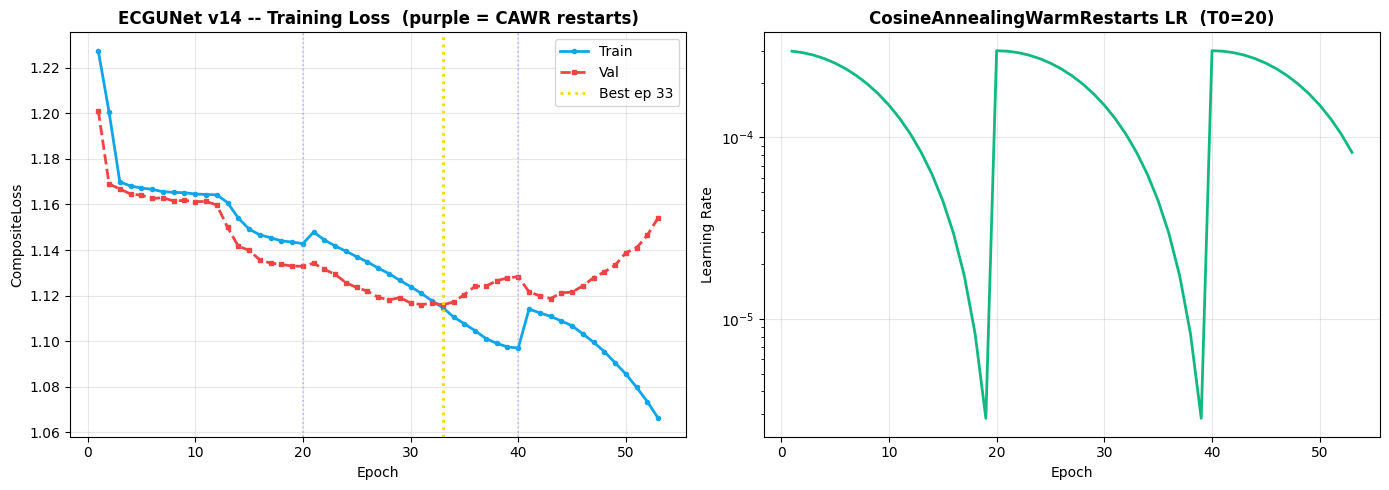

Best epoch: 33  best val: 1.11596


In [12]:
# CELL 9 -- TRAINING HISTORY PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range  = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], color='#0ea5e9', lw=2,
             label='Train', marker='o', ms=3)
axes[0].plot(ep_range, history['val_loss'], color='#ef4444', lw=2,
             label='Val', marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
for r in range(20, len(history['train_loss']), 20):
    axes[0].axvline(r, color='#a78bfa', ls=':', lw=1.2, alpha=0.6)
axes[0].set_title('ECGUNet v14 -- Training Loss  (purple = CAWR restarts)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CompositeLoss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['lr'], color='#10b981', lw=2)
axes[1].set_title('CosineAnnealingWarmRestarts LR  (T0=20)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning Rate')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_ep}  best val: {min(history["val_loss"]):.5f}')


In [13]:
# CELL 10 -- TEST EVALUATION (de-normalised mV)
test_loss, test_preds_n, test_targets_n = eval_epoch(model, cnn_te, DEVICE)
print(f'Test CompositeLoss : {test_loss:.6f}  (normalised)')

test_preds   = denormalize(test_preds_n)
test_targets = denormalize(test_targets_n)

mae_per_lead, rmse_per_lead, prd_per_lead = [], [], []
for i in range(N_LEADS):
    p, t = test_preds[:,:,i].flatten(), test_targets[:,:,i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))
    prd = 100.0 * np.sqrt(np.sum((t - p) ** 2) / (np.sum(t ** 2) + 1e-9))
    prd_per_lead.append(prd)

mae_macro  = float(np.mean(mae_per_lead))
rmse_macro = float(np.mean(rmse_per_lead))
prd_macro  = float(np.mean(prd_per_lead))

print(f"\n{'Lead':>6s}   {'MAE(mV)':>8s}   {'RMSE(mV)':>9s}   {'PRD(%)':>7s}")
print('-' * 40)
for i, name in enumerate(LEAD_NAMES):
    status = ('  OK' if prd_per_lead[i] < 25 else ('  ~' if prd_per_lead[i] < 50 else '  FAIL'))
    print(f'  {name:>4s}   {mae_per_lead[i]:8.4f}   {rmse_per_lead[i]:9.4f}   {prd_per_lead[i]:7.2f}{status}')
print('-' * 40)
print(f'  {"Macro":>4s}   {mae_macro:8.4f}   {rmse_macro:9.4f}   {prd_macro:7.2f}')
print(f'\nPRD: <10% excellent | 10-25% good | 25-50% partial | >50% FAIL')
if prd_macro < 10:
    print('EXCELLENT: ECG morphology well captured!')
elif prd_macro < 25:
    print('GOOD: morphology captured, minor amplitude errors')
elif prd_macro < 50:
    print('PARTIAL: some structure. Try raising HF_BOOST to 8.0 in Cell 6')
else:
    print('FAIL: see Cell 6 -- run sanity check, verify FFT share < 20%')


Test CompositeLoss : 1.124008  (normalised)

  Lead    MAE(mV)    RMSE(mV)    PRD(%)
----------------------------------------
     I     0.7270      1.1247     97.49  FAIL
    II     0.6717      1.0645     97.58  FAIL
   III     0.7032      1.0937     98.62  FAIL
   aVR     0.6830      1.0825     98.07  FAIL
   aVL     0.7391      1.1416     99.18  FAIL
   aVF     0.6800      1.0619     96.91  FAIL
    V1     0.7960      1.2140     98.58  FAIL
    V2     0.7336      1.1660     92.67  FAIL
    V3     0.7182      1.1604     93.20  FAIL
    V4     0.7219      1.1846     97.28  FAIL
    V5     0.7338      1.1817     97.82  FAIL
    V6     0.7443      1.1683     97.45  FAIL
----------------------------------------
  Macro     0.7210      1.1370     97.07

PRD: <10% excellent | 10-25% good | 25-50% partial | >50% FAIL
FAIL: see Cell 6 -- run sanity check, verify FFT share < 20%


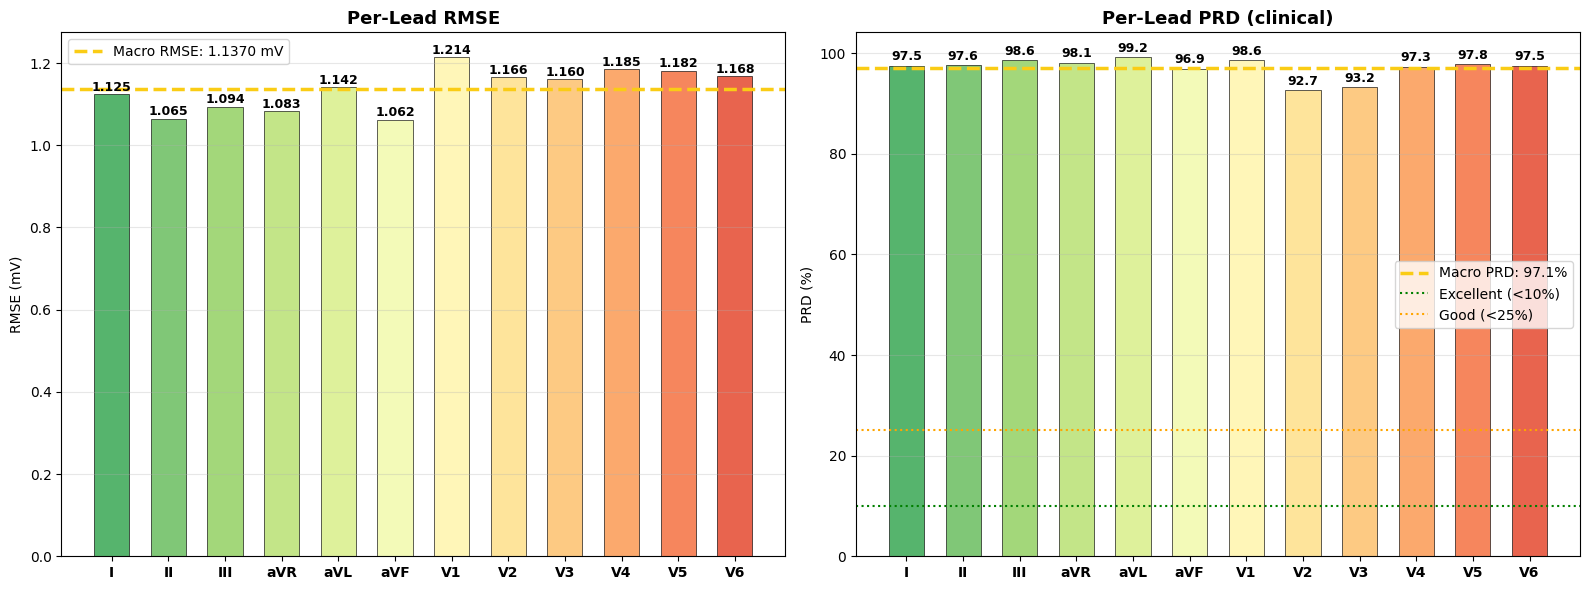

In [14]:
# CELL 11 -- PER-LEAD RMSE + PRD BARS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, N_LEADS))

bars = axes[0].bar(np.arange(N_LEADS), rmse_per_lead, width=0.62,
                   color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[0].axhline(rmse_macro, color='#facc15', ls='--', lw=2.5,
                label=f'Macro RMSE: {rmse_macro:.4f} mV')
for bar, val in zip(bars, rmse_per_lead):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(np.arange(N_LEADS))
axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('RMSE (mV)'); axes[0].set_title('Per-Lead RMSE', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(np.arange(N_LEADS), prd_per_lead, width=0.62,
                    color=colors, alpha=0.88, edgecolor='black', lw=0.5)
axes[1].axhline(prd_macro, color='#facc15', ls='--', lw=2.5,
                label=f'Macro PRD: {prd_macro:.1f}%')
axes[1].axhline(10, color='green',  ls=':', lw=1.5, label='Excellent (<10%)')
axes[1].axhline(25, color='orange', ls=':', lw=1.5, label='Good (<25%)')
for bar, val in zip(bars2, prd_per_lead):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(np.arange(N_LEADS))
axes[1].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[1].set_ylabel('PRD (%)'); axes[1].set_title('Per-Lead PRD (clinical)', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_per_lead_rmse_prd.png'), dpi=150, bbox_inches='tight')
plt.show()


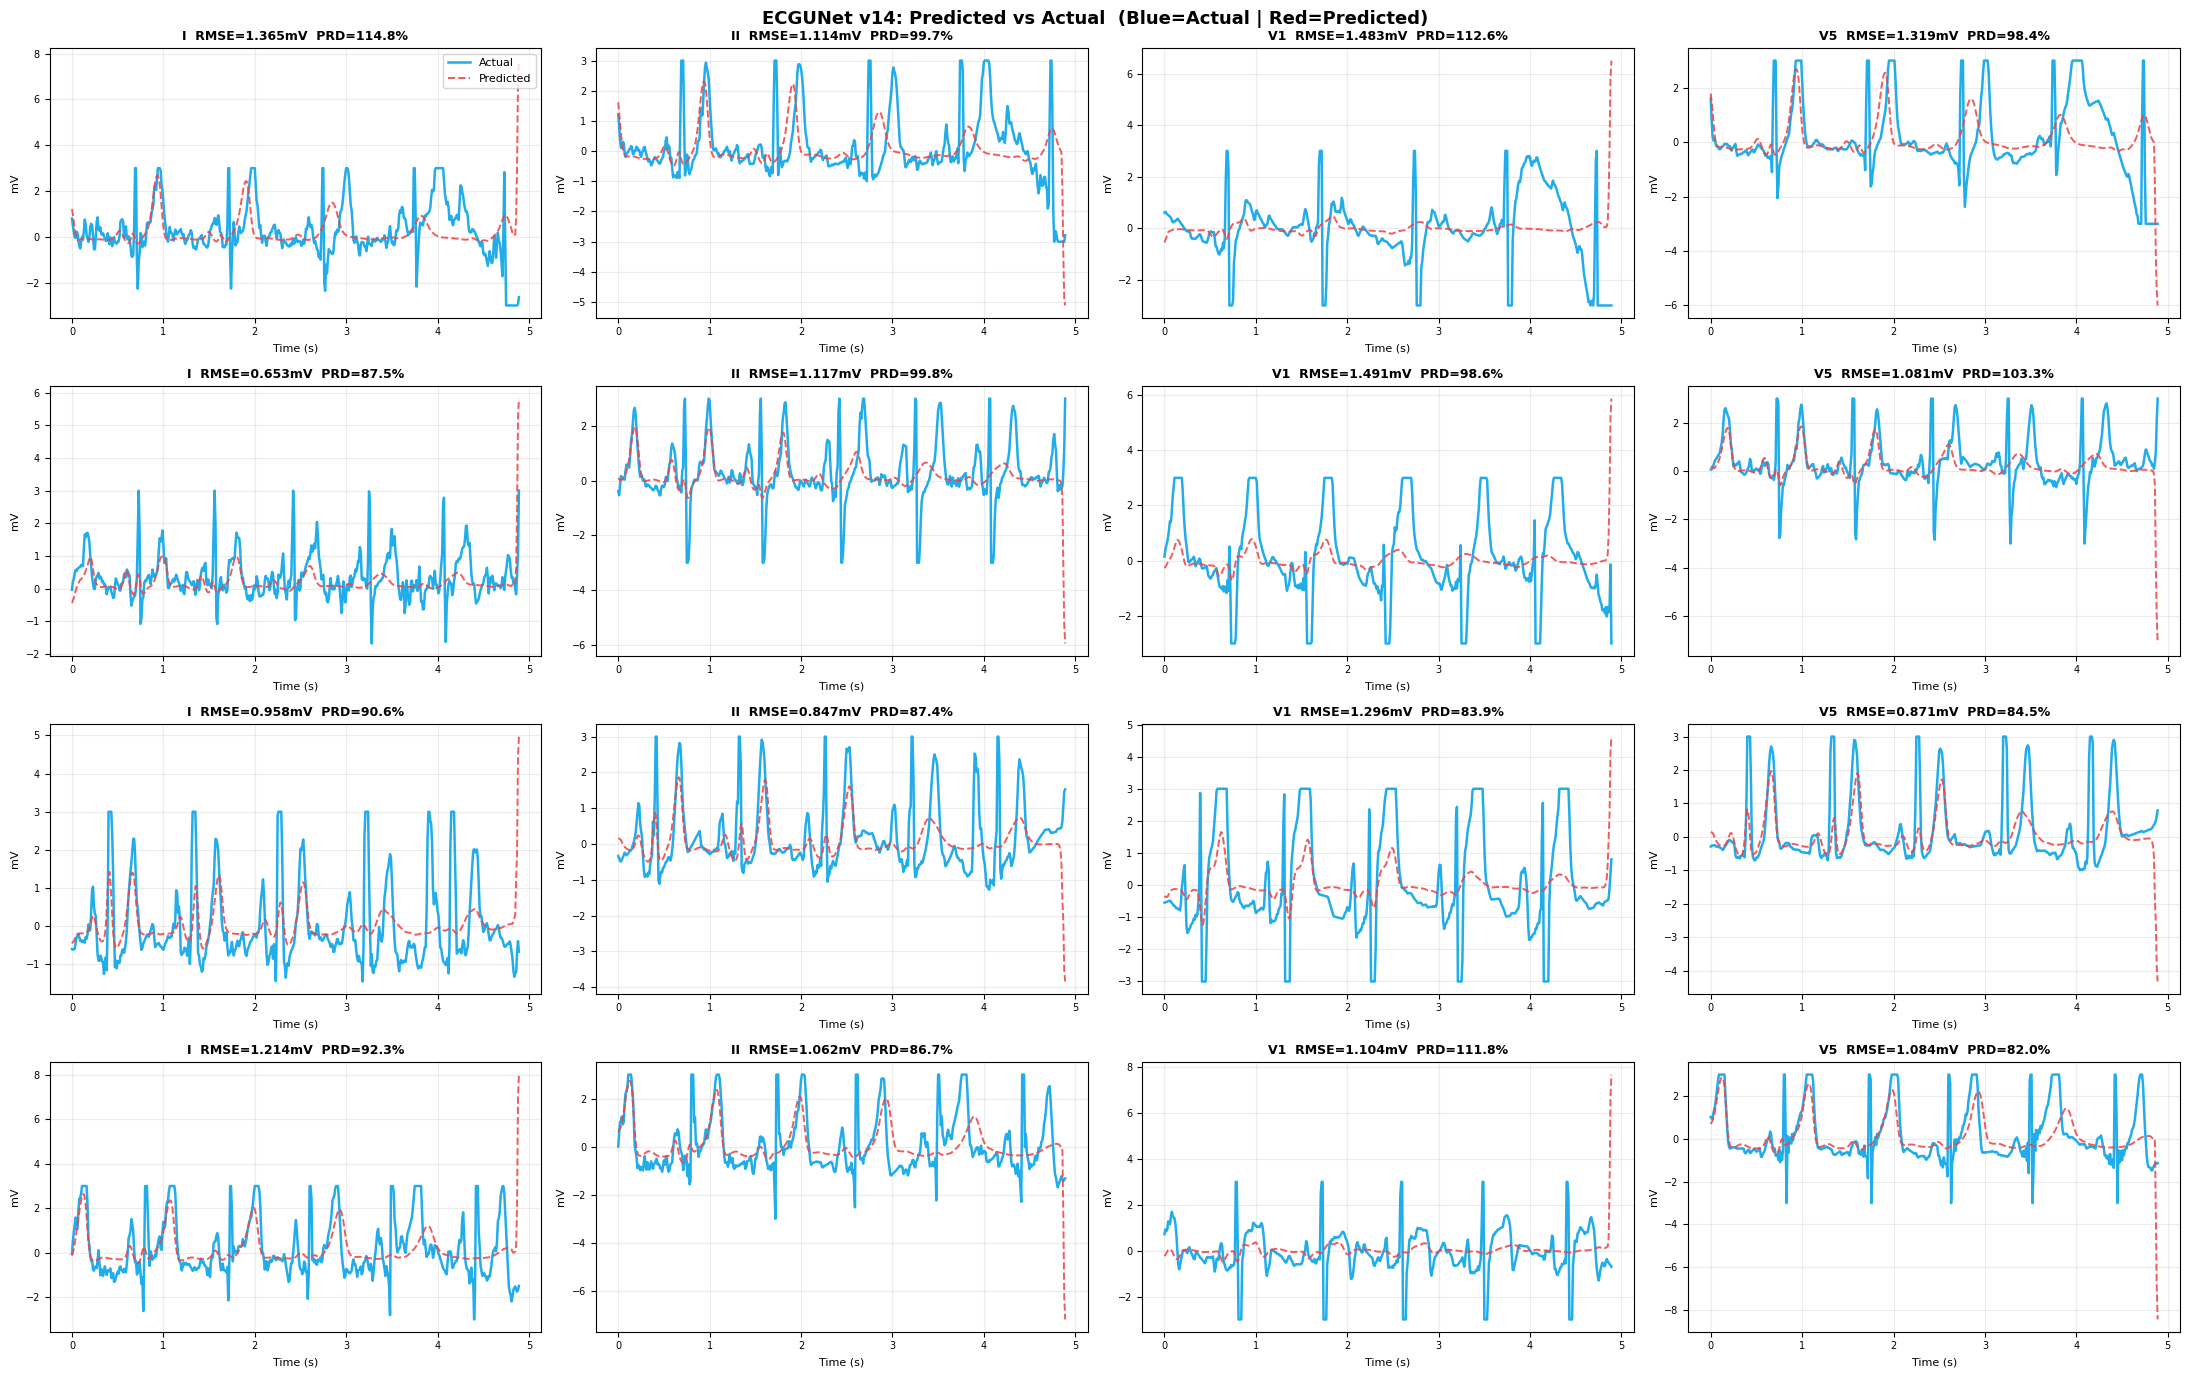

In [15]:
# CELL 12 -- PREDICTION OVERLAY (de-normalised mV)
N_ROWS       = 4
lead_indices = [LEAD_NAMES.index(l) if l in LEAD_NAMES else i
                for i, l in enumerate(['I', 'II', 'V1', 'V5'])]
lead_indices = lead_indices[:4]
t_axis       = np.arange(HORIZON) / FS

fig, axes = plt.subplots(N_ROWS, 4, figsize=(22, 14))
for row in range(N_ROWS):
    for col, li in enumerate(lead_indices):
        ax     = axes[row, col]
        actual = test_targets[row, :, li]
        pred   = test_preds[row,   :, li]
        rmse_i = np.sqrt(mean_squared_error(actual, pred))
        prd_i  = 100.0 * np.sqrt(np.sum((actual - pred)**2) / (np.sum(actual**2) + 1e-9))
        ax.plot(t_axis, actual, color='#0ea5e9', lw=1.8, label='Actual',    alpha=0.92)
        ax.plot(t_axis, pred,   color='#ef4444', lw=1.4, label='Predicted', alpha=0.88, ls='--')
        ax.set_title(f'{LEAD_NAMES[li]}  RMSE={rmse_i:.3f}mV  PRD={prd_i:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('mV', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)
        if col == 0 and row == 0:
            ax.legend(fontsize=8, loc='upper right')

fig.suptitle('ECGUNet v14: Predicted vs Actual  (Blue=Actual | Red=Predicted)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# CELL 13 -- QRS-DETECTION F1
TOL_SAMPLES = int(0.05 * FS)

def detect_peaks_ecg(sig, fs=FS):
    height = np.mean(sig) + 0.4 * np.std(sig)
    peaks, _ = find_peaks(sig, height=height, distance=int(0.25 * fs))
    return peaks

def qrs_precision_recall_f1(actual_arr, pred_arr, tol=TOL_SAMPLES):
    tp = fp = fn = 0
    for n in range(actual_arr.shape[0]):
        a_peaks = detect_peaks_ecg(actual_arr[n])
        p_peaks = detect_peaks_ecg(pred_arr[n])
        matched = set()
        for pp in p_peaks:
            if len(a_peaks) == 0:
                fp += 1; continue
            dists = np.abs(a_peaks - pp)
            best  = a_peaks[np.argmin(dists)]
            if dists.min() <= tol and best not in matched:
                matched.add(best); tp += 1
            else:
                fp += 1
        fn += len(a_peaks) - len(matched)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, tp, fp, fn

li    = LEAD_NAMES.index('II') if 'II' in LEAD_NAMES else 1
n_ev  = min(300, test_targets.shape[0])
prec, rec, f1, tp, fp, fn = qrs_precision_recall_f1(
    test_targets[:n_ev, :, li], test_preds[:n_ev, :, li])

print(f'QRS-detection on Lead {LEAD_NAMES[li]}  (n={n_ev}, tol=+/-50ms)')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision : {prec:.3f}')
print(f'  Recall    : {rec:.3f}')
print(f'  F1        : {f1:.3f}')
if f1 < 0.3:
    print('FAIL -- model not tracking individual heartbeats')
elif f1 < 0.5:
    print('Partial -- some beats detected. Try extending to 150 epochs')
else:
    print('Good -- model tracking real R-peaks!')


QRS-detection on Lead II  (n=300, tol=+/-50ms)
  TP=784  FP=1128  FN=2376
  Precision : 0.410
  Recall    : 0.248
  F1        : 0.309
Partial -- some beats detected. Try extending to 150 epochs


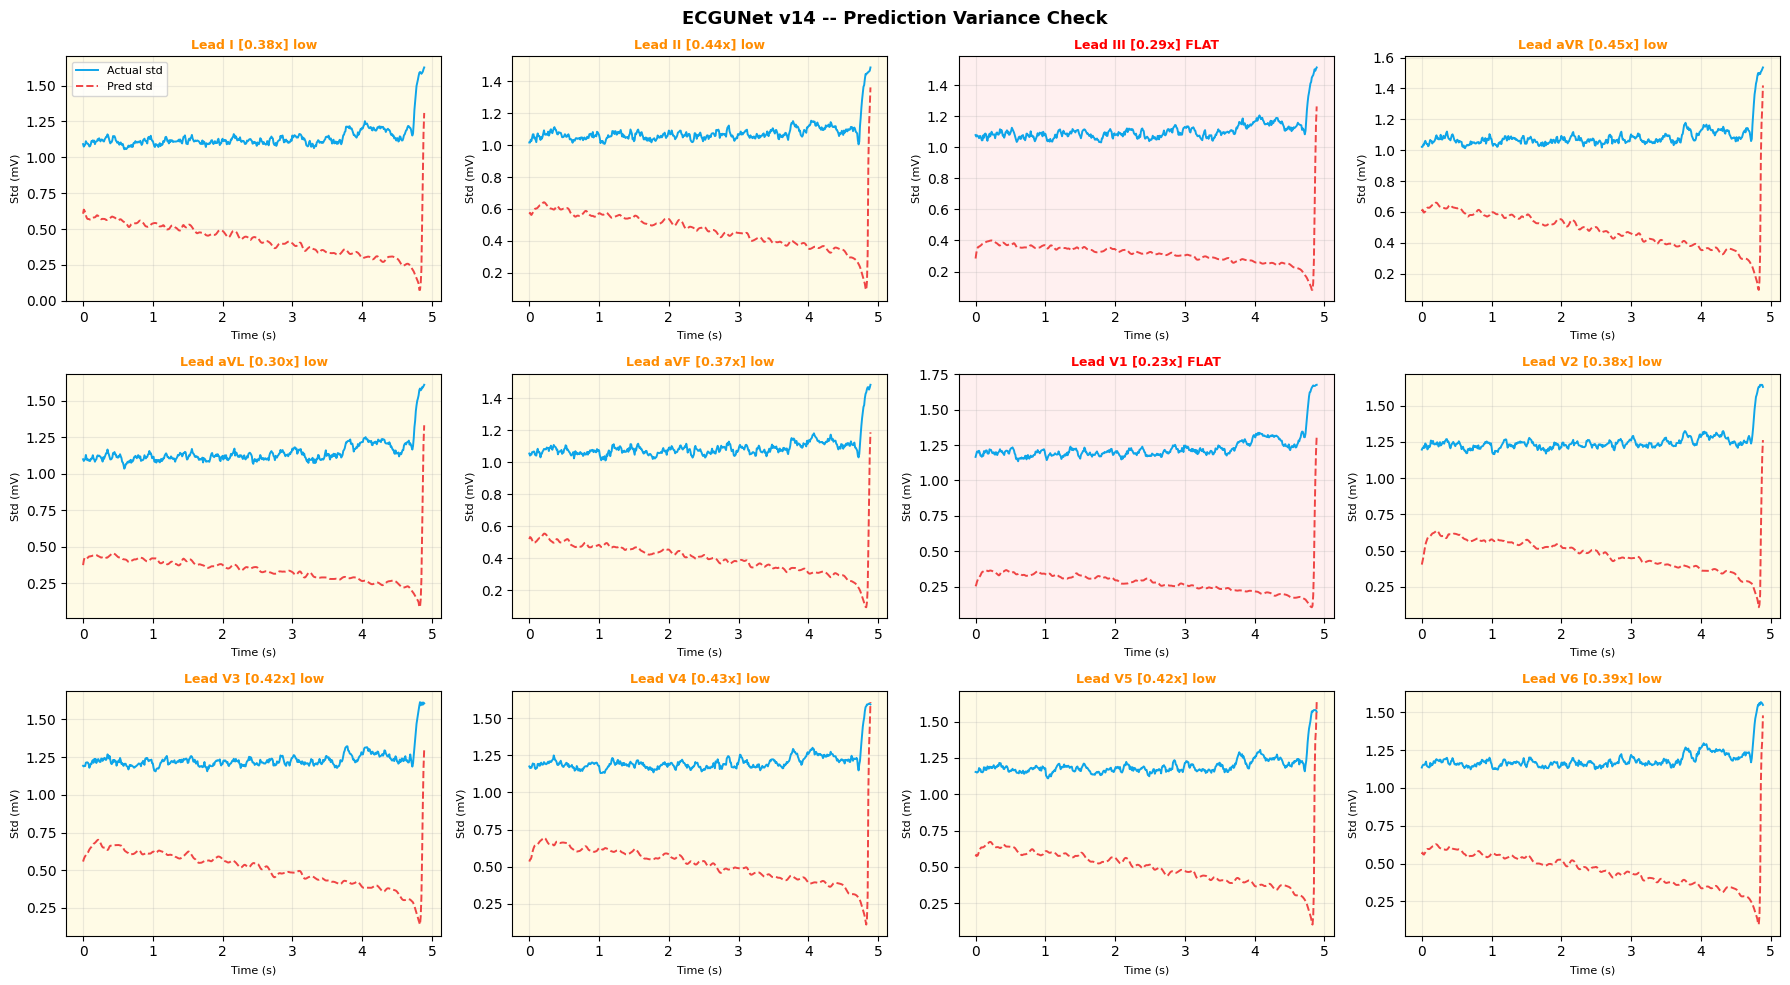

Flat leads: ['III', 'V1']  -> Raise HF_BOOST to 8.0 in Cell 6


In [17]:
# CELL 14 -- PREDICTION VARIANCE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t_axis   = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
flat_leads, low_leads = [], []
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t_axis, true_std[:,i], color='#0ea5e9', lw=1.4, label='Actual std')
    ax.plot(t_axis, pred_std[:,i], color='#ef4444', lw=1.4, label='Pred std', ls='--')
    ratio = pred_std[:,i].mean() / (true_std[:,i].mean() + 1e-9)
    ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('Std (mV)', fontsize=8)
    ax.grid(alpha=0.25)
    if i == 0: ax.legend(fontsize=8)
    if ratio < 0.3:
        ax.set_facecolor('#fff0f0')
        ax.set_title(f'Lead {name} [{ratio:.2f}x] FLAT', color='red', fontweight='bold', fontsize=9)
        flat_leads.append(name)
    elif ratio < 0.6:
        ax.set_facecolor('#fffbe6')
        ax.set_title(f'Lead {name} [{ratio:.2f}x] low', color='darkorange', fontweight='bold', fontsize=9)
        low_leads.append(name)
    else:
        ax.set_title(f'Lead {name} [{ratio:.2f}x] OK', fontweight='bold', fontsize=9)

fig.suptitle('ECGUNet v14 -- Prediction Variance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_variance_check.png'), dpi=150, bbox_inches='tight')
plt.show()

if flat_leads and len(flat_leads) == N_LEADS:
    print('ALL LEADS FLAT: model outputting near-constant predictions.')
    print('  -> Re-run Cell 6 sanity check, verify FFT share < 20%')
    print('  -> Verify X (past) and y (future) are non-overlapping windows')
elif flat_leads:
    print(f'Flat leads: {flat_leads}  -> Raise HF_BOOST to 8.0 in Cell 6')
elif low_leads:
    print(f'Low-variance leads: {low_leads}  -> train longer or raise GRAD_WEIGHT to 4.0')
else:
    ov = pred_std.mean() / true_std.mean()
    print(f'OK Variance tracking. Overall ratio = {ov:.2f}x')


In [18]:
# CELL 15 -- SAVE RESULTS
results = dict(
    model='ECGUNet_v14_CNN_BiLSTM_UNet_NormFFT',
    horizon_s=HORIZON/FS, input_s=INPUT_LEN/FS,
    n_parameters=n_params,
    test_loss=float(test_loss),
    mae_per_lead=mae_per_lead, mae_macro=mae_macro,
    rmse_per_lead=rmse_per_lead, rmse_macro=rmse_macro,
    prd_per_lead=prd_per_lead, prd_macro=prd_macro,
    qrs_precision=float(prec), qrs_recall=float(rec), qrs_f1=float(f1),
    loss_config=dict(huber_delta=HUBER_DELTA, grad_weight=GRAD_WEIGHT,
                     fft_weight=FFT_WEIGHT, hf_boost=HF_BOOST,
                     hf_cutoff=HF_CUTOFF, fft_normalized=True),
    norm=dict(mu=NORM_MU, sigma=NORM_SIGMA),
    history=history, lead_names=LEAD_NAMES,
    test_preds=test_preds, test_targets=test_targets,
)
res_path = os.path.join(CKPT_DIR, 'ECG_CNN_v14_results.pkl')
with open(res_path, 'wb') as f:
    pickle.dump(results, f)

print(f'\n{"="*64}')
print(f'  ECGUNet v14 FINAL  ({INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s)')
print(f'{"="*64}')
print(f'  Architecture  : CNN-BiLSTM U-Net (skip connections)')
print(f'  Loss          : Huber + GradL1 + NormalizedFocalFFT')
print(f'  Parameters    : {n_params:,}')
print(f'  Macro MAE     : {mae_macro:.6f} mV')
print(f'  Macro RMSE    : {rmse_macro:.6f} mV')
print(f'  Macro PRD     : {prd_macro:.2f}%   (<10% excellent, <25% good)')
print(f'  QRS F1        : {f1:.3f}  (P={prec:.3f} R={rec:.3f})')
print(f'{"="*64}')
print(f'  Checkpoint : {CKPT_DIR}/ECG_CNN_v14_best.pt')
print(f'  Results    : {res_path}')
print('OK v14 complete')



  ECGUNet v14 FINAL  (4.9s -> 4.9s)
  Architecture  : CNN-BiLSTM U-Net (skip connections)
  Loss          : Huber + GradL1 + NormalizedFocalFFT
  Parameters    : 4,283,340
  Macro MAE     : 0.720992 mV
  Macro RMSE    : 1.136995 mV
  Macro PRD     : 97.07%   (<10% excellent, <25% good)
  QRS F1        : 0.309  (P=0.410 R=0.248)
  Checkpoint : /content/drive/MyDrive/his/HIS Project/reports/checkpoints/ECG_CNN_v14_best.pt
  Results    : /content/drive/MyDrive/his/HIS Project/reports/checkpoints/ECG_CNN_v14_results.pkl
OK v14 complete
